# RFI analysis of 327 MHz Deuterium line

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import json

def k(x):
    return x*1000

In [2]:
file = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2024-10-08T12.sigmf-data'
meta = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2024-10-08T12.sigmf-meta'
data = np.memmap(file, dtype='f4')

with open(meta) as m:
    m = json.load(m)

data = data.reshape(-1, 600000)

min_f = m['global']['antenna:low_frequency']
max_f = m['global']['antenna:high_frequency']
rate = m['global']['core:sample_rate']
period = 1/ rate
f_resolution = (max_f - min_f) / k(600)

print(f"Min Frequency: {min_f/1e6} MHz")
print(f"Max Frequency: {max_f/1e6} MHz")
print(f"Sample Rate: {rate/1e6} MHz")
print(f"Period: {period} s")
print(f"Frequency Resolution: {f_resolution/1e6} MHz")

def convert_frequency_to_index(f):
    """ Function which converts input frequency in MHz to index,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using inverse of
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']

    return int((f*1e6 - min_f)*k(600)/(max_f-min_f))

def convert_index_to_frequency(i):
    """ Function which converts input index to frequency in MHz,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']   
    return (i*(max_f-min_f)/k(600) + min_f)/1e6

Min Frequency: 20.0 MHz
Max Frequency: 6000.0 MHz
Sample Rate: 1.3333333333333332e-06 MHz
Period: 0.75 s
Frequency Resolution: 0.009966666666666665 MHz


### The RFI Monitor cycles peridocially, A clean stretch from time index 500 to 1500 is used for further analysis

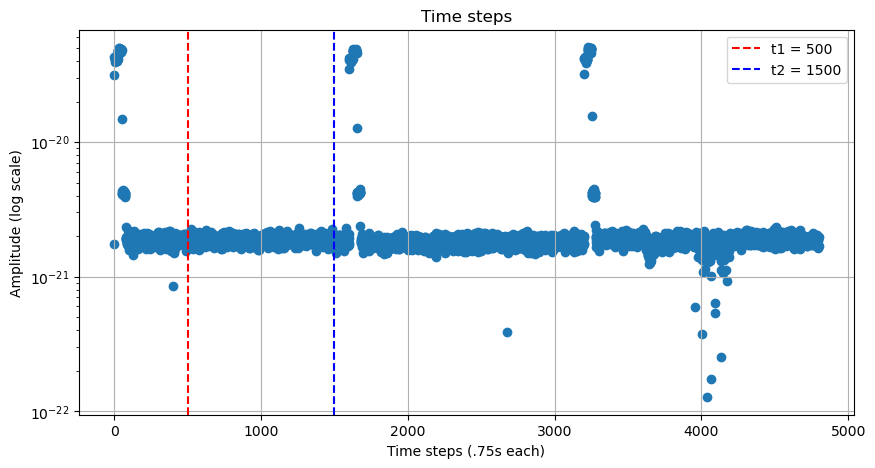

In [ ]:
t1 = 500
t2 = 1500

plt.figure(figsize=(10, 5))
plt.scatter(np.arange(4800), data[0:4800, k(400)])
# for i, txt in enumerate(np.arange(180)):
#     plt.annotate(f'{txt:.2e}', (np.arange(180)[i], data[0:180, k(400)][i]), fontsize=8, rotation=45)
plt.title("Time steps")
plt.yscale('log')
plt.xlabel("Time steps (.75s each)")
plt.ylabel("Amplitude (log scale)")
plt.grid(True)
plt.axvline(x=t1, color='r', linestyle='--', label=f't1 = {t1}')
plt.axvline(x=t2, color='b', linestyle='--', label=f't2 = {t2}')
plt.legend()
plt.show()

## Large scale picture showing RFI in the 280-330 MHz range.

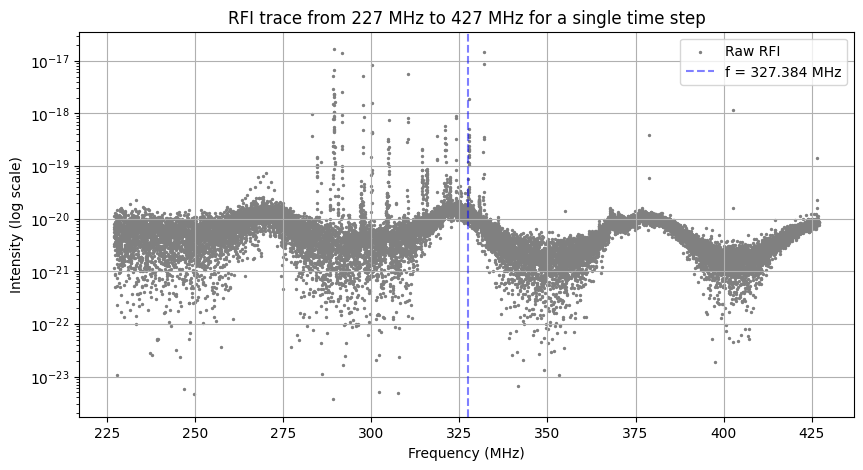

In [19]:
min_f = 227
max_f = 427
n = 1000

min_i = convert_frequency_to_index(min_f)
max_i = convert_frequency_to_index(max_f)

x_vals_i = np.arange(min_i, max_i)
x_vals_f = convert_index_to_frequency(x_vals_i)

frequency_range = x_vals_f

plt.figure(figsize=(10,5))

# plot a few raw traces
plt.scatter(frequency_range, data[t1, min_i:max_i], label='Raw RFI', color='grey', s=2)

plt.axvline(x=327.384, color='b', alpha=0.5, linestyle='--', label='f = 327.384 MHz')

# switch to log scale before annotating
plt.yscale('log')
plt.legend()
plt.title("RFI trace from 227 MHz to 427 MHz for a single time step")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Intensity (log scale)")
plt.grid(True)
plt.show()

In [ ]:
min_f = 326
max_f = 329
n = 1000

min_i = convert_frequency_to_index(min_f)
max_i = convert_frequency_to_index(max_f)

x_vals_i = np.arange(min_i, max_i)
x_vals_f = convert_index_to_frequency(x_vals_i)

frequency_range = x_vals_f

# slice out the block we want to summarize
data_slice = data[t1:t2, min_i:max_i]
data_slice = np.where(data_slice > 1e-25, data_slice, np.nan)  # ignore non-positive values

# geometric mean (ignore non‐positive values)
geo_means = np.exp(np.log(data_slice).mean(axis=0))

# geometric std (multiplicative): exp(std(log(x))) ignoring non‐positive
log_data = np.where(data_slice > 0, np.log(data_slice), np.nan)
geo_stds  = np.exp(np.nanstd(log_data, axis=0))

print("Means shape:", geo_means.shape)
print("Stds shape:",  geo_stds.shape)

Means shape: (50167,)
Stds shape: (50167,)


/usr/local/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Zoom in to see the area directly around 327MHz including with mean RFI from 1000 time steps per frequency bin.

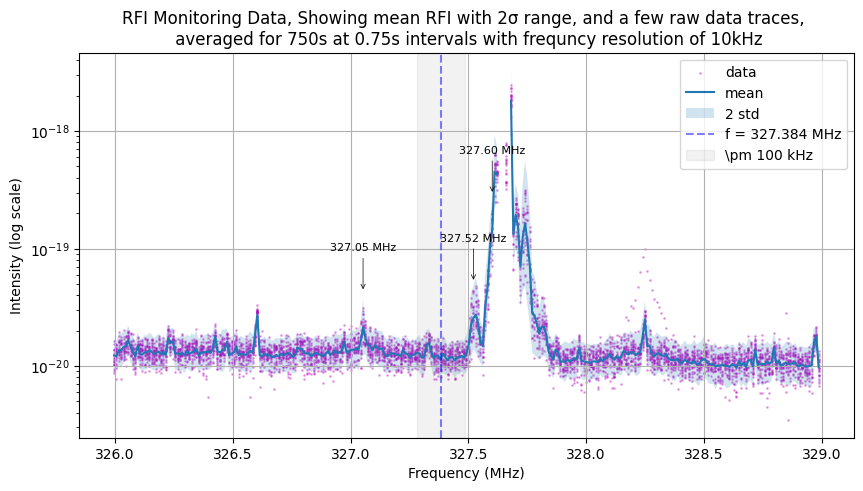

In [24]:
plt.figure(figsize=(10,5))

# plot a few raw traces
for j in range(t1, t2, 50):
    plt.scatter(x_vals_f, data[j, x_vals_i],
                c='m', s=1, alpha=0.3, label='data' if j==t1 else None)

# plot mean and ±2σ
plt.plot(frequency_range, geo_means, label='mean')
plt.fill_between(frequency_range,
                 geo_means/(geo_stds**2),
                 geo_means*(geo_stds**2),
                 alpha=0.2, label='2 std')
plt.axvline(x=327.384, color='b', alpha=0.5, linestyle='--', label='f = 327.384 MHz')
plt.axvspan(327.284, 327.484, color='grey', alpha=0.1, label='\pm 100 kHz')

# switch to log scale before annotating
plt.yscale('log')

# ensure idx is defined first
idx = 100

# update y-limits based on idx
ax = plt.gca()
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, max(ymax, geo_means[idx]*3))

# annotate with a larger fontsize
for idx in [106, 153, 161]:
    ax.annotate(
        f'{frequency_range[idx]:.2f} MHz',
        xy=(frequency_range[idx], geo_means[idx]*2),
        xytext=(frequency_range[idx], geo_means[idx]*4.5),
        textcoords='data',
        arrowprops=dict(arrowstyle='->', lw=0.5),
        ha='center',
        fontsize=8,   # increased fontsize for visibility
        clip_on=False,
        zorder=10
    )

plt.legend()
plt.title("RFI Monitoring Data, Showing mean RFI with 2σ range, and a few raw data traces, \n averaged for 750s at 0.75s intervals with frequncy resolution of 10kHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Intensity (log scale)")
plt.grid(True)
plt.show()

In [9]:
summed_data = np.sum(data[t1:t2, min_i:max_i], axis=0)
print("Summed data shape:", summed_data.shape)

Summed data shape: (301,)


## Integration of 1000 timesteps instead of averaging.

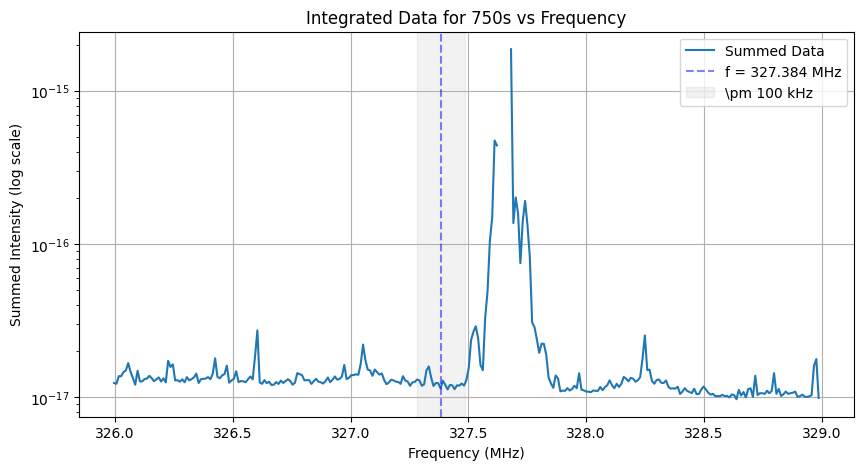

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(frequency_range, summed_data, label='Summed Data')
plt.axvline(x=327.384, color='b', alpha=0.5, linestyle='--', label='f = 327.384 MHz')
plt.axvspan(327.284, 327.484, color='grey', alpha=0.1, label='\pm 100 kHz')
plt.yscale('log')
plt.title("Integrated Data for 750s vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Summed Intensity (log scale)")
plt.grid(True)
plt.legend()
plt.show()